In [ ]:


import torch
from transformers import AutoProcessor, LlavaForConditionalGeneration, BitsAndBytesConfig
from PIL import Image

model_id = "llava-hf/llava-1.5-7b-hf"

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

processor = AutoProcessor.from_pretrained(model_id)
model = LlavaForConditionalGeneration.from_pretrained(
    model_id,
    quantization_config=quantization_config,
    device_map="auto",
    attn_implementation="eager",
    low_cpu_mem_usage=True
)

image = Image.new('RGB', (336, 336), color='blue')
prompt = "USER: <image>\nFind the dog. ASSISTANT:"
inputs = processor(text=prompt, images=image, return_tensors="pt").to(model.device)

print(inputs["input_ids"].shape)
print(inputs["input_ids"][0])

def hook_fwd(m, i, o):
    print(m.__class__.__name__)
    if isinstance(o, tuple):
        for idx, val in enumerate(o):
            if isinstance(val, torch.Tensor):
                print(f"Tuple {idx} shape: {val.shape}")
    elif isinstance(o, torch.Tensor):
        print(f"Tensor shape: {o.shape}")

def hook_bwd(m, gi, go):
    print(m.__class__.__name__ + " BWD")
    for idx, val in enumerate(go):
        if isinstance(val, torch.Tensor):
            print(f"Grad {idx} shape: {val.shape}")

hooks = []
for name, module in model.named_modules():
    if name == "language_model.model.layers.31.self_attn":
        hooks.append(module.register_forward_hook(hook_fwd))
        hooks.append(module.register_full_backward_hook(hook_bwd))

outputs = model(**inputs, output_attentions=True)
loss = outputs.logits.sum()
loss.backward()

for h in hooks:
    h.remove()

if hasattr(outputs, 'attentions') and outputs.attentions is not None:
    print("outputs.attentions[-1] shape:", outputs.attentions[-1].shape)

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/686 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


torch.Size([1, 592])
tensor([    1,  3148,  1001, 29901, 29871, 32000, 32000, 32000, 32000, 32000,
        32000, 32000, 32000, 32000, 32000, 32000, 32000, 32000, 32000, 32000,
        32000, 32000, 32000, 32000, 32000, 32000, 32000, 32000, 32000, 32000,
        32000, 32000, 32000, 32000, 32000, 32000, 32000, 32000, 32000, 32000,
        32000, 32000, 32000, 32000, 32000, 32000, 32000, 32000, 32000, 32000,
        32000, 32000, 32000, 32000, 32000, 32000, 32000, 32000, 32000, 32000,
        32000, 32000, 32000, 32000, 32000, 32000, 32000, 32000, 32000, 32000,
        32000, 32000, 32000, 32000, 32000, 32000, 32000, 32000, 32000, 32000,
        32000, 32000, 32000, 32000, 32000, 32000, 32000, 32000, 32000, 32000,
        32000, 32000, 32000, 32000, 32000, 32000, 32000, 32000, 32000, 32000,
        32000, 32000, 32000, 32000, 32000, 32000, 32000, 32000, 32000, 32000,
        32000, 32000, 32000, 32000, 32000, 32000, 32000, 32000, 32000, 32000,
        32000, 32000, 32000, 32000, 32000, 

In [ ]:
!pip install -q bitsandbytes

In [ ]:
!kaggle datasets download -d hsankesara/flickr-image-dataset

Dataset URL: https://www.kaggle.com/datasets/hsankesara/flickr-image-dataset
License(s): CC0-1.0
100% 8.16G/8.16G [08:00<00:00, 18.3MB/s]



In [ ]:
import zipfile
import os

with zipfile.ZipFile('flickr-image-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('flickr30k_images')

print(os.listdir('flickr30k_images'))

['flickr30k_images']


In [ ]:
import os
import subprocess

REPO_DIR = "flickr30k_entities-master"

if not os.path.exists(REPO_DIR):
    subprocess.run(["wget", "-O", "master.zip", "https://github.com/BryanPlummer/flickr30k_entities/archive/refs/heads/master.zip"], check=True)
    subprocess.run(["unzip", "-o", "master.zip"], check=True)
    os.remove("master.zip")

In [ ]:
import os
import xml.etree.ElementTree as ET
from collections import defaultdict
from PIL import Image
import zipfile

IMAGE_DIR = "/content/flickr30k_images/flickr30k_images/flickr30k_images"
REPO_DIR = "flickr30k_entities-master"

if not os.path.exists(REPO_DIR):
    print("Annotation repo not found.")
    raise SystemExit(1)

ANNO_ZIP = os.path.join(REPO_DIR, "annotations.zip")
if os.path.exists(ANNO_ZIP) and not os.path.exists(os.path.join(REPO_DIR, "Annotations")):
    print("Extracting annotations...")
    with zipfile.ZipFile(ANNO_ZIP, 'r') as zip_ref:
        zip_ref.extractall(REPO_DIR)

with open(os.path.join(REPO_DIR, "test.txt"), "r") as f:
    test_image_ids = [line.strip().split('.')[0] for line in f]

print(f"Test image IDs: {len(test_image_ids)}")
print("First 5:", test_image_ids[:5])

missing = []
existing = []
for img_id in test_image_ids:
    for ext in ['.jpg', '.jpeg', '.png']:
        path = os.path.join(IMAGE_DIR, f"{img_id}{ext}")
        if os.path.exists(path):
            existing.append(img_id)
            break
    else:
        missing.append(img_id)

print(f"Images found: {len(existing)}")
if missing:
    print(f"Missing: {len(missing)} (first 5: {missing[:5]})")
else:
    print("All test images present.")

if existing:
    sample_ids = existing[:3]
    print("Loading sample images...")
    for img_id in sample_ids:
        for ext in ['.jpg', '.jpeg', '.png']:
            path = os.path.join(IMAGE_DIR, f"{img_id}{ext}")
            if os.path.exists(path):
                try:
                    img = Image.open(path).convert("RGB")
                    print(f"Loaded {img_id} ({img.size})")
                except Exception as e:
                    print(f"Failed {img_id}: {e}")
                break

if existing:
    sample_id = existing[0]
    print(f"Sample phrases for {sample_id}:")
    xml_path = os.path.join(REPO_DIR, "Annotations", f"{sample_id}.xml")
    if os.path.exists(xml_path):
        tree = ET.parse(xml_path)
        root = tree.getroot()
        chain_to_phrase = {}
        sent_path = os.path.join(REPO_DIR, "Sentences", f"{sample_id}.txt")
        if os.path.exists(sent_path):
            with open(sent_path, 'r') as f:
                lines = f.readlines()
                for line in lines[1:]:
                    if '#' in line:
                        parts = line.strip().split('#')
                        if len(parts) == 2:
                            chain_id, phrase = parts[0], parts[1]
                            chain_to_phrase[chain_id] = phrase
        for obj in root.iter('object'):
            chain_id = obj.find('name').text
            phrase = chain_to_phrase.get(chain_id, chain_id)
            print(f"  - {phrase}")
    else:
        print("  XML not found.")

print("Verification complete.")
if missing:
    print("Some images missing. Check IMAGE_DIR and file naming (e.g., 1016887272.jpg).")
else:
    print("All ready for benchmark.")

Extracting annotations...
Test image IDs: 1000
First 5: ['1016887272', '7162685234', '3000017878', '4971484184', '92679312']
Images found: 1000
All test images present.
Loading sample images...
Loaded 1016887272 ((333, 500))
Loaded 7162685234 ((500, 333))
Loaded 3000017878 ((500, 281))
Sample phrases for 1016887272:
  - 547
  - 547
  - 547
  - 547
  - 547
  - 547
  - 547
  - 548
  - 549
  - 550
  - 550
  - 551
  - 554
Verification complete.
All ready for benchmark.


In [ ]:
import os
import re
import xml.etree.ElementTree as ET
from PIL import Image

IMAGE_DIR = "flickr30k_images"
REPO_DIR = "flickr30k_entities-master"

def parse_phrases(sent_path):
    chain_to_phrase = {}
    if not os.path.exists(sent_path):
        return chain_to_phrase
    with open(sent_path, 'r') as f:
        lines = f.readlines()
        for line in lines[1:]:
            pattern = r'\[/EN#(\d+)/[^ ]+ (.*?)\]'
            matches = re.findall(pattern, line)
            for chain_id, phrase in matches:
                chain_to_phrase[chain_id] = phrase.strip()
    return chain_to_phrase

sample_id = "1016887272"
sent_path = os.path.join(REPO_DIR, "Sentences", f"{sample_id}.txt")
phrases = parse_phrases(sent_path)
print(f"Parsed phrases for image {sample_id}:")
for cid, ph in list(phrases.items())[:5]:
    print(f"   chain {cid} -> '{ph}'")

xml_path = os.path.join(REPO_DIR, "Annotations", f"{sample_id}.xml")
if os.path.exists(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    print(f"\nObjects from XML (first 5):")
    for i, obj in enumerate(root.iter('object')):
        if i >= 5:
            break
        chain_id = obj.find('name').text
        bbox_elem = obj.find('bndbox')
        if bbox_elem is not None:
            xmin = int(bbox_elem.find('xmin').text)
            ymin = int(bbox_elem.find('ymin').text)
            xmax = int(bbox_elem.find('xmax').text)
            ymax = int(bbox_elem.find('ymax').text)
            phrase = phrases.get(chain_id, chain_id)
            print(f"   chain {chain_id} -> phrase '{phrase}'  bbox: [{xmin},{ymin},{xmax},{ymax}]")

print("\n" + "=" * 60)
print("VERIFICATION COMPLETE".center(60, "="))
print("If you see actual phrases (not just chain IDs), parsing is correct.")
print("=" * 60)

Parsed phrases for image 1016887272:
   chain 547 -> 'A collage of one person'
   chain 548 -> 'a cliff'
   chain 549 -> 'one man'
   chain 551 -> 'the rope'

Objects from XML (first 5):
   chain 547 -> phrase 'A collage of one person'  bbox: [194,370,231,454]
   chain 547 -> phrase 'A collage of one person'  bbox: [208,304,256,384]
   chain 547 -> phrase 'A collage of one person'  bbox: [188,239,227,307]
   chain 547 -> phrase 'A collage of one person'  bbox: [165,205,205,261]
   chain 547 -> phrase 'A collage of one person'  bbox: [177,164,229,215]

===================VERIFICATION COMPLETE====================
If you see actual phrases (not just chain IDs), parsing is correct.


In [ ]:
print("Top-level modules:")
for name, child in model.named_children():
    print(name)

print("\nVision module hierarchy:")
vision_modules = [name for name, module in model.named_modules() if "vision" in name.lower()]
for name in vision_modules[:10]:
    print(name)
if len(vision_modules) > 10:
    print("...")
    for name in vision_modules[-5:]:
        print(name)

Top-level modules:
model
lm_head

Vision module hierarchy:
model.vision_tower
model.vision_tower.embeddings
model.vision_tower.embeddings.patch_embedding
model.vision_tower.embeddings.position_embedding
model.vision_tower.pre_layrnorm
model.vision_tower.encoder
model.vision_tower.encoder.layers
model.vision_tower.encoder.layers.0
model.vision_tower.encoder.layers.0.self_attn
model.vision_tower.encoder.layers.0.self_attn.k_proj
...
model.vision_tower.encoder.layers.23.mlp.activation_fn
model.vision_tower.encoder.layers.23.mlp.fc1
model.vision_tower.encoder.layers.23.mlp.fc2
model.vision_tower.encoder.layers.23.layer_norm2
model.vision_tower.post_layernorm


In [ ]:
import torch
import numpy as np
from scipy.linalg import eigh
from transformers import AutoProcessor, LlavaForConditionalGeneration, BitsAndBytesConfig
from tqdm import tqdm
import warnings
import logging
import os
import zipfile
import xml.etree.ElementTree as ET
from collections import defaultdict
from PIL import Image
import re
import random

IMAGE_DIR = "/content/flickr30k_images/flickr30k_images/flickr30k_images"
REPO_DIR = "flickr30k_entities-master"
NUM_EVALS = 1000
SHUFFLE = True
GRID_SIZE = 24

logging.basicConfig(level=logging.ERROR)
warnings.filterwarnings("ignore")

model_id = "llava-hf/llava-1.5-7b-hf"
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

processor = AutoProcessor.from_pretrained(model_id)
model = LlavaForConditionalGeneration.from_pretrained(
    model_id,
    quantization_config=quantization_config,
    device_map={"": 0},
    attn_implementation="eager",
    low_cpu_mem_usage=True
)
model.eval()

def parse_phrases(sent_path):
    chain_to_phrase = {}
    if not os.path.exists(sent_path):
        return chain_to_phrase
    with open(sent_path, 'r') as f:
        lines = f.readlines()
        for line in lines[1:]:
            pattern = r'\[/EN#(\d+)/[^ ]+ (.*?)\]'
            matches = re.findall(pattern, line)
            for chain_id, phrase in matches:
                chain_to_phrase[chain_id] = phrase.strip()
    return chain_to_phrase

if not os.path.exists(REPO_DIR):
    import subprocess
    subprocess.run(["wget", "-O", "master.zip", "https://github.com/BryanPlummer/flickr30k_entities/archive/refs/heads/master.zip"], check=True)
    subprocess.run(["unzip", "-o", "master.zip"], check=True)
    os.remove("master.zip")

ANNO_ZIP = os.path.join(REPO_DIR, "annotations.zip")
if os.path.exists(ANNO_ZIP) and not os.path.exists(os.path.join(REPO_DIR, "Annotations")):
    with zipfile.ZipFile(ANNO_ZIP, 'r') as zip_ref:
        zip_ref.extractall(REPO_DIR)

with open(os.path.join(REPO_DIR, "test.txt"), "r") as f:
    test_image_ids = [line.strip().split('.')[0] for line in f]

image_to_objects = defaultdict(list)
for img_id in test_image_ids:
    xml_path = os.path.join(REPO_DIR, "Annotations", f"{img_id}.xml")
    if not os.path.exists(xml_path):
        continue
    try:
        tree = ET.parse(xml_path)
    except:
        continue
    root = tree.getroot()
    sent_path = os.path.join(REPO_DIR, "Sentences", f"{img_id}.txt")
    chain_to_phrase = parse_phrases(sent_path)
    for obj in root.iter('object'):
        chain_id = obj.find('name').text
        bbox_elem = obj.find('bndbox')
        if bbox_elem is None:
            continue
        xmin = int(bbox_elem.find('xmin').text)
        ymin = int(bbox_elem.find('ymin').text)
        xmax = int(bbox_elem.find('xmax').text)
        ymax = int(bbox_elem.find('ymax').text)
        phrase = chain_to_phrase.get(chain_id, chain_id)
        image_to_objects[img_id].append({
            'category_name': phrase,
            'bbox': [xmin, ymin, xmax - xmin, ymax - ymin]
        })

methods = ["Raw Attention", "Attention Rollout", "ViT-Grad-CAM", "Attn x Grad (Chefer)", "Deep-Spec (Ours)"]
hits = {m: 0 for m in methods}
results_per_sample = {m: [] for m in methods}
total_evaluated = 0

def extract_all_heatmaps(inputs, tgt_rel, img_start, img_end, text_indices):
    heatmaps = {}


    with torch.no_grad():
        outputs_nograd = model(**inputs, output_attentions=True)
        all_layers_attn = torch.stack(outputs_nograd.attentions).detach().cpu().squeeze(1)
        avg_attn = all_layers_attn.mean(dim=(0, 1))

        #  Raw Attention
        hm_raw = avg_attn[tgt_rel][:, img_start:img_end].max(dim=0).values.reshape(GRID_SIZE, GRID_SIZE)
        hm_raw = hm_raw / (hm_raw.max() + 1e-10)
        heatmaps["Raw Attention"] = hm_raw.numpy()

        #  Attention Rollout
        S_len = avg_attn.shape[0]
        rollout = torch.eye(S_len)
        for layer_attn in all_layers_attn:
            avg_heads = layer_attn.mean(dim=0)
            avg_heads = 0.5 * avg_heads + 0.5 * torch.eye(S_len)
            rollout = rollout @ avg_heads
        hm_roll = rollout[tgt_rel][:, img_start:img_end].max(dim=0).values.reshape(GRID_SIZE, GRID_SIZE)
        hm_roll = hm_roll / (hm_roll.max() + 1e-10)
        heatmaps["Attention Rollout"] = hm_roll.numpy()

        #  Deep-Spec (Ours)
        W_c = avg_attn[text_indices][:, img_start:img_end]
        W_c = W_c / (W_c.max() + 1e-10)
        W_c_np = W_c.numpy()

        T_ds, I_ds = W_c_np.shape
        N = T_ds + I_ds
        W = np.zeros((N, N))
        W[:T_ds, T_ds:] = W_c_np
        W[T_ds:, :T_ds] = W_c_np.T
        W = W + 1e-3

        D = np.sum(W, axis=1)
        D_inv_sqrt = np.diag(1.0 / np.sqrt(D))
        L_sym = np.eye(N) - D_inv_sqrt @ W @ D_inv_sqrt
        _, eigvecs = eigh(L_sym)

        K_components = 5
        V_text = eigvecs[:T_ds, 1:K_components+1]
        V_img = eigvecs[T_ds:, 1:K_components+1]
        denoised_affinity = V_text @ V_img.T

        tgt_rel_mapped = [text_indices.index(idx) for idx in tgt_rel]
        target_affinity = np.abs(denoised_affinity[tgt_rel_mapped, :])
        hm_ds = target_affinity.max(axis=0).reshape(GRID_SIZE, GRID_SIZE)
        hm_ds = (hm_ds - hm_ds.min()) / (hm_ds.max() - hm_ds.min() + 1e-10)
        heatmaps["Deep-Spec (Ours)"] = hm_ds

        del outputs_nograd
        del all_layers_attn
        torch.cuda.empty_cache()

    # Chefer, Grad-CAM
    activations, gradients = None, None

    def fwd_hook(m, inp, out):
        nonlocal activations
        activations = out[0].detach()

    def bwd_hook(m, gin, gout):
        nonlocal gradients
        gradients = gout[0].detach()

    target_layer = None
    for name, m in model.named_modules():
        if name == "model.vision_tower.encoder.layers.23":
            target_layer = m
            break

    h1 = target_layer.register_forward_hook(fwd_hook)
    h2 = target_layer.register_full_backward_hook(bwd_hook)

    inputs["pixel_values"].requires_grad_(True)
    model.zero_grad()

    try:
        outputs = model(**inputs, output_attentions=True, output_hidden_states=True)

        if hasattr(outputs, 'logits'):
            del outputs.logits
            torch.cuda.empty_cache()

        for a in outputs.attentions:
            a.retain_grad()

        loss = outputs.hidden_states[-1][0, tgt_rel].sum()
        loss.backward()

        if gradients is not None and activations is not None:
            if activations.shape[1] == 577:
                acts = activations[0, 1:]
                grads = gradients[0, 1:]
            else:
                acts = activations[0]
                grads = gradients[0]
            weights = grads.mean(dim=0)
            cam = (weights * acts).sum(dim=-1)
            cam = torch.relu(cam)
            if cam.shape[0] == 576:
                cam = cam.reshape(GRID_SIZE, GRID_SIZE)
                if cam.max() > 0:
                    cam = cam / (cam.max() + 1e-10)
                heatmaps["ViT-Grad-CAM"] = cam.cpu().numpy()
            else:
                heatmaps["ViT-Grad-CAM"] = np.zeros((GRID_SIZE, GRID_SIZE))
        else:
            heatmaps["ViT-Grad-CAM"] = np.zeros((GRID_SIZE, GRID_SIZE))

        S_len = outputs.attentions[0].shape[-1]
        heatmap_chefer = torch.zeros((S_len, S_len), device="cpu")
        count = 0
        for a in outputs.attentions:
            if a.grad is not None:
                grad = a.grad.detach().cpu().squeeze(0)
                attn = a.detach().cpu().squeeze(0)
                heatmap_chefer += (attn * grad).mean(dim=0)
                count += 1

        if count > 0:
            heatmap_chefer = heatmap_chefer / count
            heatmap_chefer = torch.clamp(heatmap_chefer, min=0)
            hm_chefer = heatmap_chefer[tgt_rel][:, img_start:img_end].max(dim=0).values.reshape(GRID_SIZE, GRID_SIZE)
            if hm_chefer.max() > 0:
                hm_chefer = hm_chefer / (hm_chefer.max() + 1e-10)
            heatmaps["Attn x Grad (Chefer)"] = hm_chefer.numpy()
        else:
            heatmaps["Attn x Grad (Chefer)"] = np.zeros((GRID_SIZE, GRID_SIZE))

    except RuntimeError as e:
        if "out of memory" in str(e).lower():
            heatmaps["ViT-Grad-CAM"] = np.zeros((GRID_SIZE, GRID_SIZE))
            heatmaps["Attn x Grad (Chefer)"] = np.zeros((GRID_SIZE, GRID_SIZE))
        else:
            raise e
    finally:
        h1.remove()
        h2.remove()
        del outputs
        torch.cuda.empty_cache()

    return heatmaps

if SHUFFLE:
    random.shuffle(test_image_ids)

print("\n--- Starting Evaluation Run ---")
evaluated = 0
with tqdm(total=NUM_EVALS, desc="Evaluating", unit="obj") as pbar:
    for img_id in test_image_ids:
        if evaluated >= NUM_EVALS:
            break
        if img_id not in image_to_objects:
            continue
        objects = image_to_objects[img_id]
        img_path = None
        for ext in ['.jpg', '.jpeg', '.png']:
            candidate = os.path.join(IMAGE_DIR, f"{img_id}{ext}")
            if os.path.exists(candidate):
                img_path = candidate
                break
        if img_path is None:
            continue

        try:
            image = Image.open(img_path).convert("RGB")
        except:
            continue
        orig_W, orig_H = image.size

        sent_path = os.path.join(REPO_DIR, "Sentences", f"{img_id}.txt")
        if not os.path.exists(sent_path):
            continue
        with open(sent_path, 'r') as f:
            caption = f.readline().strip()
        if not caption:
            continue

        target_noun = None
        for obj in objects:
            phrase = obj['category_name']
            if phrase.lower() in caption.lower():
                target_noun = phrase
                break
        if not target_noun:
            continue
        all_target_bboxes = [obj['bbox'] for obj in objects if obj['category_name'] == target_noun]

        prompt = f"USER: <image>\n{caption}\nASSISTANT:"
        inputs = processor(text=prompt, images=image, return_tensors="pt").to(model.device)
        input_ids = inputs["input_ids"][0]

        img_starts = (input_ids == 32000).nonzero(as_tuple=True)[0]
        if len(img_starts) == 0:
            continue
        img_start = img_starts[0].item()
        img_end = img_start + 576

        text_indices = list(range(img_end, len(input_ids)))
        if not text_indices:
            continue

        tokens = processor.tokenizer.convert_ids_to_tokens(input_ids)
        target_indices = []
        for i in text_indices:
            t = tokens[i]
            clean_token = t.lower().replace(" ", "").replace(" ", "").replace("_", "")
            if any(word in clean_token or clean_token in word for word in target_noun.lower().split()):
                target_indices.append(i)

        if not target_indices:
            continue
        tgt_rel = target_indices

        heatmaps = extract_all_heatmaps(inputs, tgt_rel, img_start, img_end, text_indices)
        if heatmaps is None:
            continue

        for m_name in methods:
            hm = heatmaps[m_name]
            if hm.max() == 0:
                continue
            max_idx = np.argmax(hm)
            max_y_patch, max_x_patch = np.unravel_index(max_idx, hm.shape)
            rel_x = (max_x_patch + 0.5) / GRID_SIZE
            rel_y = (max_y_patch + 0.5) / GRID_SIZE
            pixel_x = rel_x * orig_W
            pixel_y = rel_y * orig_H
            hit = False
            for bbox in all_target_bboxes:
                x_min, y_min, bbox_w, bbox_h = bbox
                x_max, y_max = x_min + bbox_w, y_min + bbox_h
                if (x_min <= pixel_x <= x_max) and (y_min <= pixel_y <= y_max):
                    hit = True
                    break
            if hit:
                hits[m_name] += 1
            results_per_sample[m_name].append(1 if hit else 0)

        evaluated += 1
        pbar.update(1)
        if evaluated % 100 == 0:
            pbar.write(f"\n--- Pointing Game Accuracy ({evaluated}/{NUM_EVALS}) ---")
            for m_name in methods:
                acc = (hits[m_name] / evaluated) * 100
                pbar.write(f"{m_name:<25} | {acc:.1f}%")
            pbar.write("-" * 50)

print("\n" + "=" * 60)
print(" FINAL FLICKR30K POINTING GAME ACCURACY (Phrase Grounding) ".center(60))
print("=" * 60)
print(f"{'Method':<25} | {'Hit Acc (%)':<12} | {'Variance':<10} | {'Std Dev':<10}")
print("-" * 60)
for m_name in methods:
    arr = np.array(results_per_sample[m_name])
    acc = arr.mean() * 100 if len(arr) > 0 else 0
    var = arr.var(ddof=1) if len(arr) > 1 else 0.0
    std = arr.std(ddof=1) if len(arr) > 1 else 0.0
    prefix = ">> " if "Deep-Spec" in m_name else "   "
    print(f"{prefix}{m_name:<22} | {acc:>10.2f} | {var:>10.4f} | {std:>10.4f}")
print("=" * 60)

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/686 [00:00<?, ?it/s]


--- Starting Evaluation Run ---


Evaluating:  10%|█         | 100/1000 [15:12<2:21:08,  9.41s/obj]


--- Pointing Game Accuracy (100/1000) ---
Raw Attention             | 27.0%
Attention Rollout         | 15.0%
ViT-Grad-CAM              | 0.0%
Attn x Grad (Chefer)      | 28.0%
Deep-Spec (Ours)          | 38.0%
--------------------------------------------------


...


--- Pointing Game Accuracy (700/1000) ---
Raw Attention             | 25.1%
Attention Rollout         | 13.7%
ViT-Grad-CAM              | 0.0%
Attn x Grad (Chefer)      | 30.0%
Deep-Spec (Ours)          | 41.4%
--------------------------------------------------


Evaluating:  80%|████████  | 800/1000 [1:58:56<29:49,  8.95s/obj]


--- Pointing Game Accuracy (800/1000) ---
Raw Attention             | 25.2%
Attention Rollout         | 13.8%
ViT-Grad-CAM              | 0.0%
Attn x Grad (Chefer)      | 30.0%
Deep-Spec (Ours)          | 42.5%
--------------------------------------------------


Evaluating:  87%|████████▋ | 872/1000 [2:09:18<18:58,  8.90s/obj]


 FINAL FLICKR30K POINTING GAME ACCURACY (Phrase Grounding)  
Method                    | Hit Acc (%)  | Variance   | Std Dev   
------------------------------------------------------------
   Raw Attention          |      25.11 |     0.1883 |     0.4339
   Attention Rollout      |      13.53 |     0.1171 |     0.3423
   ViT-Grad-CAM           |       0.00 |     0.0000 |     0.0000
   Attn x Grad (Chefer)   |      30.16 |     0.2109 |     0.4592
>> Deep-Spec (Ours)       |      41.97 |     0.2438 |     0.4938


Total Evaluated Samples: 872
------------------------------------------------------------
 EXCLUSIVE HITS (Only this method got it right) 
------------------------------------------------------------
Raw Attention             | 22
Attention Rollout         | 26
ViT-Grad-CAM              | 0
Attn x Grad (Chefer)      | 40
Deep-Spec (Ours)          | 121
------------------------------------------------------------


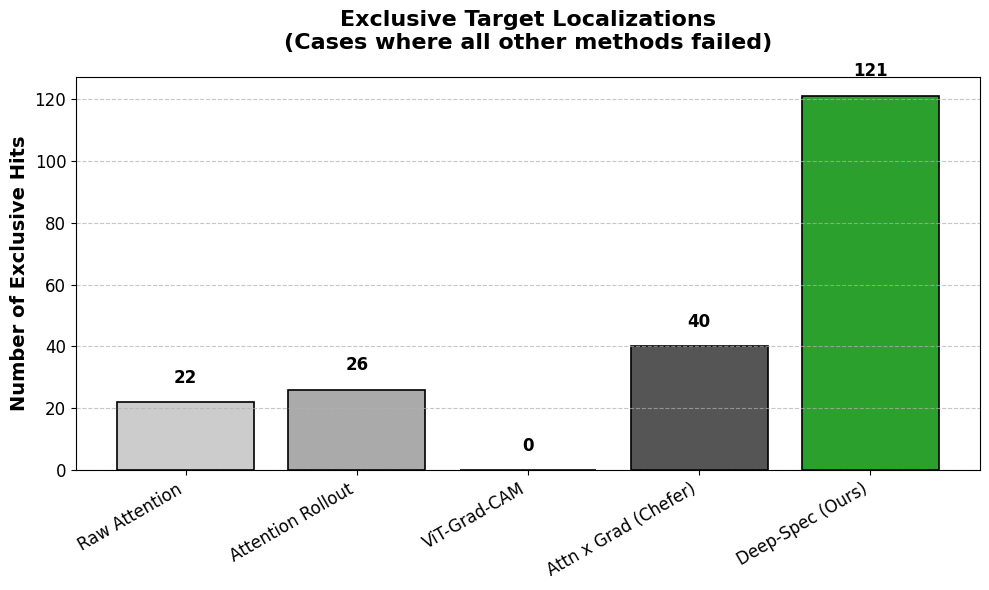

[8, 21, 33, 40, 48, 58, 63, 65, 72, 85, 96, 97, 102, 103, 122, 132, 136, 137, 138, 158]


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

num_samples = len(results_per_sample["Deep-Spec (Ours)"])
exclusive_hits_count = {m: 0 for m in methods}
exclusive_indices = {m: [] for m in methods}

for i in range(num_samples):
    hits_for_sample = []
    for m in methods:
        if i < len(results_per_sample[m]) and results_per_sample[m][i] == 1:
            hits_for_sample.append(m)

    if len(hits_for_sample) == 1:
        exclusive_m = hits_for_sample[0]
        exclusive_hits_count[exclusive_m] += 1
        exclusive_indices[exclusive_m].append(i)

print(f"Total Evaluated Samples: {num_samples}")
print("-" * 60)
print(" EXCLUSIVE HITS (Only this method got it right) ")
print("-" * 60)
for m in methods:
    print(f"{m:<25} | {exclusive_hits_count[m]}")
print("-" * 60)

plt.figure(figsize=(10, 6))
colors = ['#cccccc', '#aaaaaa', '#888888', '#555555', '#2ca02c']
bars = plt.bar(methods, [exclusive_hits_count[m] for m in methods], color=colors, edgecolor='black', linewidth=1.2)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, int(yval), ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.title("Exclusive Target Localizations\n(Cases where all other methods failed)", fontsize=16, pad=20, fontweight='bold')
plt.ylabel("Number of Exclusive Hits", fontsize=14, fontweight='bold')
plt.xticks(rotation=30, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

pdf_filename = "Deep_Spec_Exclusive_Hits_LLaVA-flickr30k.pdf"
plt.savefig(pdf_filename, format="pdf", dpi=300, bbox_inches='tight')
plt.show()

print(exclusive_indices["Deep-Spec (Ours)"][:20])

In [ ]:
import torch
import numpy as np
from scipy.linalg import eigh
from transformers import AutoProcessor, LlavaForConditionalGeneration, BitsAndBytesConfig
from datasets import load_dataset
from tqdm import tqdm
import warnings
import logging
import os
import json
import requests
import zipfile
from io import BytesIO
from PIL import Image
import re
import random
import matplotlib.pyplot as plt


logging.basicConfig(level=logging.ERROR)
warnings.filterwarnings("ignore")

NUM_EVALS = 1000
GRID_SIZE = 24
model_id = "llava-hf/llava-1.5-7b-hf"

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

processor = AutoProcessor.from_pretrained(model_id)
model = LlavaForConditionalGeneration.from_pretrained(
    model_id,
    quantization_config=quantization_config,
    device_map={"": 0},
    attn_implementation="eager",
    low_cpu_mem_usage=True
)
model.eval()


ANNOTATION_FILE = "instances_val2017.json"
if not os.path.exists(ANNOTATION_FILE):
    print("Downloading MS-COCO validation bounding boxes...")
    r = requests.get("http://images.cocodataset.org/annotations/annotations_trainval2017.zip", stream=True)
    with open("annotations.zip", 'wb') as f:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)
    with zipfile.ZipFile("annotations.zip", 'r') as zip_ref:
        zip_ref.extract("annotations/instances_val2017.json", ".")
    os.rename("annotations/instances_val2017.json", ANNOTATION_FILE)
    if os.path.exists("annotations.zip"): os.remove("annotations.zip")
    import shutil
    if os.path.exists("annotations"): shutil.rmtree("annotations")
    print("Download complete.")

with open(ANNOTATION_FILE, 'r') as f:
    coco_data = json.load(f)

categories = {cat['id']: cat['name'] for cat in coco_data['categories']}
image_to_objects = {}
for ann in coco_data['annotations']:
    img_id = ann['image_id']
    if img_id not in image_to_objects:
        image_to_objects[img_id] = []
    image_to_objects[img_id].append({
        'category_name': categories[ann['category_id']],
        'bbox': ann['bbox']
    })

print(f"Loaded MS COCO annotations for {len(image_to_objects)} images.")
dataset = load_dataset("phiyodr/coco2017", split="validation", streaming=True)


methods = ["Raw Attention", "Attention Rollout", "ViT-Grad-CAM", "Attn x Grad (Chefer)", "Deep-Spec (Ours)"]
hits = {m: 0 for m in methods}
results_per_sample = {m: [] for m in methods}
total_evaluated = 0


def extract_all_heatmaps(inputs, tgt_rel, img_start, img_end, text_indices):
    heatmaps = {}

    with torch.no_grad():
        outputs_nograd = model(**inputs, output_attentions=True)
        all_layers_attn = torch.stack(outputs_nograd.attentions).detach().cpu().squeeze(1)
        avg_attn = all_layers_attn.mean(dim=(0, 1))

        hm_raw = avg_attn[tgt_rel][:, img_start:img_end].max(dim=0).values.reshape(GRID_SIZE, GRID_SIZE)
        hm_raw = hm_raw / (hm_raw.max() + 1e-10)
        heatmaps["Raw Attention"] = hm_raw.numpy()

        # Attention Rollout
        S_len = avg_attn.shape[0]
        rollout = torch.eye(S_len)
        for layer_attn in all_layers_attn:
            avg_heads = layer_attn.mean(dim=0)
            avg_heads = 0.5 * avg_heads + 0.5 * torch.eye(S_len)
            rollout = rollout @ avg_heads
        hm_roll = rollout[tgt_rel][:, img_start:img_end].max(dim=0).values.reshape(GRID_SIZE, GRID_SIZE)
        hm_roll = hm_roll / (hm_roll.max() + 1e-10)
        heatmaps["Attention Rollout"] = hm_roll.numpy()

        # Deep-Spec (Ours)
        W_c = avg_attn[text_indices][:, img_start:img_end]
        W_c = W_c / (W_c.max() + 1e-10)
        W_c_np = W_c.numpy()

        T_ds, I_ds = W_c_np.shape
        N = T_ds + I_ds
        W = np.zeros((N, N))
        W[:T_ds, T_ds:] = W_c_np
        W[T_ds:, :T_ds] = W_c_np.T
        W = W + 1e-3

        D = np.sum(W, axis=1)
        D_inv_sqrt = np.diag(1.0 / np.sqrt(D))
        L_sym = np.eye(N) - D_inv_sqrt @ W @ D_inv_sqrt
        _, eigvecs = eigh(L_sym)

        K_components = 5
        V_text = eigvecs[:T_ds, 1:K_components+1]
        V_img = eigvecs[T_ds:, 1:K_components+1]
        denoised_affinity = V_text @ V_img.T

        tgt_rel_mapped = [text_indices.index(idx) for idx in tgt_rel]
        target_affinity = np.abs(denoised_affinity[tgt_rel_mapped, :])
        hm_ds = target_affinity.max(axis=0).reshape(GRID_SIZE, GRID_SIZE)
        hm_ds = (hm_ds - hm_ds.min()) / (hm_ds.max() - hm_ds.min() + 1e-10)
        heatmaps["Deep-Spec (Ours)"] = hm_ds

        del outputs_nograd
        del all_layers_attn
        torch.cuda.empty_cache()

    # Chefer, Grad-CAM
    activations, gradients = None, None

    def fwd_hook(m, inp, out):
        nonlocal activations
        activations = out[0].detach()

    def bwd_hook(m, gin, gout):
        nonlocal gradients
        gradients = gout[0].detach()

    target_layer = None
    for name, m in model.named_modules():
        if name == "model.vision_tower.encoder.layers.23":
            target_layer = m
            break

    h1 = target_layer.register_forward_hook(fwd_hook)
    h2 = target_layer.register_full_backward_hook(bwd_hook)

    inputs["pixel_values"].requires_grad_(True)
    model.zero_grad()

    try:
        outputs = model(**inputs, output_attentions=True, output_hidden_states=True)

        if hasattr(outputs, 'logits'):
            del outputs.logits
            torch.cuda.empty_cache()

        for a in outputs.attentions:
            a.retain_grad()

        loss = outputs.hidden_states[-1][0, tgt_rel].sum()
        loss.backward()

        if gradients is not None and activations is not None:
            if activations.shape[1] == 577:
                acts = activations[0, 1:]
                grads = gradients[0, 1:]
            else:
                acts = activations[0]
                grads = gradients[0]
            weights = grads.mean(dim=0)
            cam = (weights * acts).sum(dim=-1)
            cam = torch.relu(cam)
            if cam.shape[0] == 576:
                cam = cam.reshape(GRID_SIZE, GRID_SIZE)
                if cam.max() > 0: cam = cam / (cam.max() + 1e-10)
                heatmaps["ViT-Grad-CAM"] = cam.cpu().numpy()
            else:
                heatmaps["ViT-Grad-CAM"] = np.zeros((GRID_SIZE, GRID_SIZE))
        else:
            heatmaps["ViT-Grad-CAM"] = np.zeros((GRID_SIZE, GRID_SIZE))

        S_len = outputs.attentions[0].shape[-1]
        heatmap_chefer = torch.zeros((S_len, S_len), device="cpu")
        count = 0
        for a in outputs.attentions:
            if a.grad is not None:
                grad = a.grad.detach().cpu().squeeze(0)
                attn = a.detach().cpu().squeeze(0)
                heatmap_chefer += (attn * grad).mean(dim=0)
                count += 1

        if count > 0:
            heatmap_chefer = heatmap_chefer / count
            heatmap_chefer = torch.clamp(heatmap_chefer, min=0)
            hm_chefer = heatmap_chefer[tgt_rel][:, img_start:img_end].max(dim=0).values.reshape(GRID_SIZE, GRID_SIZE)
            if hm_chefer.max() > 0: hm_chefer = hm_chefer / (hm_chefer.max() + 1e-10)
            heatmaps["Attn x Grad (Chefer)"] = hm_chefer.numpy()
        else:
            heatmaps["Attn x Grad (Chefer)"] = np.zeros((GRID_SIZE, GRID_SIZE))

    except RuntimeError as e:
        if "out of memory" in str(e).lower():
            heatmaps["ViT-Grad-CAM"] = np.zeros((GRID_SIZE, GRID_SIZE))
            heatmaps["Attn x Grad (Chefer)"] = np.zeros((GRID_SIZE, GRID_SIZE))
        else:
            raise e
    finally:
        h1.remove()
        h2.remove()
        del outputs
        torch.cuda.empty_cache()

    return heatmaps


print(f"\nStarting Large-Scale LLaVA-7B Pointing Game on MS COCO ({NUM_EVALS} objects)...\n")
iterator = iter(dataset)

with tqdm(total=NUM_EVALS, desc="Evaluating", unit="obj") as pbar:
    while total_evaluated < NUM_EVALS:
        try:
            data = next(iterator)
            image_id = data.get('image_id')

            if image_id not in image_to_objects: continue
            objects = image_to_objects[image_id]

            if 'image' in data and data['image'] is not None:
                image = data['image'].convert("RGB")
            elif 'coco_url' in data:
                try:
                    response = requests.get(data['coco_url'], timeout=10)
                    image = Image.open(BytesIO(response.content)).convert("RGB")
                except: continue
            else: continue

            orig_W, orig_H = image.size
            caption = data['captions'][0] if isinstance(data.get('captions'), list) else data.get('text', "")
            if not caption: continue

            target_noun = None
            for obj in objects:
                if obj['category_name'].lower() in caption.lower():
                    target_noun = obj['category_name']
                    break

            if not target_noun: continue
            all_target_bboxes = [obj['bbox'] for obj in objects if obj['category_name'] == target_noun]

            prompt = f"USER: <image>\n{caption}\nASSISTANT:"
            inputs = processor(text=prompt, images=image, return_tensors="pt").to(model.device)
            input_ids = inputs["input_ids"][0]

            img_starts = (input_ids == 32000).nonzero(as_tuple=True)[0]
            if len(img_starts) == 0: continue
            img_start = img_starts[0].item()
            img_end = img_start + 576

            text_indices = list(range(img_end, len(input_ids)))
            if not text_indices: continue

            tokens = processor.tokenizer.convert_ids_to_tokens(input_ids)
            target_indices = []
            for i in text_indices:
                t = tokens[i]
                clean_token = t.lower().replace(" ", "").replace(" ", "").replace("_", "")
                if any(word in clean_token or clean_token in word for word in target_noun.lower().split()):
                    target_indices.append(i)

            if not target_indices: continue
            tgt_rel = target_indices

            heatmaps = extract_all_heatmaps(inputs, tgt_rel, img_start, img_end, text_indices)
            if heatmaps is None: continue

            for m_name in methods:
                hm = heatmaps[m_name]
                if hm.max() == 0:
                    results_per_sample[m_name].append(0)
                    continue

                max_idx = np.argmax(hm)
                max_y_patch, max_x_patch = np.unravel_index(max_idx, hm.shape)
                rel_x = (max_x_patch + 0.5) / GRID_SIZE
                rel_y = (max_y_patch + 0.5) / GRID_SIZE
                pixel_x = rel_x * orig_W
                pixel_y = rel_y * orig_H

                hit = False
                for bbox in all_target_bboxes:
                    x_min, y_min, bbox_w, bbox_h = bbox
                    x_max, y_max = x_min + bbox_w, y_min + bbox_h
                    if (x_min <= pixel_x <= x_max) and (y_min <= pixel_y <= y_max):
                        hit = True
                        break

                if hit: hits[m_name] += 1
                results_per_sample[m_name].append(1 if hit else 0)

            total_evaluated += 1
            pbar.update(1)

            if total_evaluated % 100 == 0:
                pbar.write(f"\n--- Pointing Game Accuracy ({total_evaluated}/{NUM_EVALS}) ---")
                for m_name in methods:
                    acc = (hits[m_name] / total_evaluated) * 100
                    pbar.write(f"{m_name:<25} | {acc:.1f}%")
                pbar.write("-" * 50)

        except StopIteration:
            break
        except Exception as e:
            continue




print("\n" + "=" * 60)
print(" FINAL MS COCO POINTING GAME ACCURACY (LLaVA-7B) ".center(60))
print("=" * 60)
print(f"{'Method':<25} | {'Hit Acc (%)':<12} | {'Variance':<10} | {'Std Dev':<10}")
print("-" * 60)
for m_name in methods:
    arr = np.array(results_per_sample[m_name])
    acc = arr.mean() * 100 if len(arr) > 0 else 0
    var = arr.var(ddof=1) if len(arr) > 1 else 0.0
    std = arr.std(ddof=1) if len(arr) > 1 else 0.0
    prefix = ">> " if "Deep-Spec" in m_name else "   "
    print(f"{prefix}{m_name:<22} | {acc:>10.2f} | {var:>10.4f} | {std:>10.4f}")
print("=" * 60)

num_samples = len(results_per_sample["Deep-Spec (Ours)"])
exclusive_hits_count = {m: 0 for m in methods}
for i in range(num_samples):
    hits_for_sample = [m for m in methods if results_per_sample[m][i] == 1]
    if len(hits_for_sample) == 1:
        exclusive_m = hits_for_sample[0]
        exclusive_hits_count[exclusive_m] += 1

print(f"\nTotal Evaluated Samples: {num_samples}")
print("-" * 60)
print(" EXCLUSIVE HITS (Only this method got it right) ")
print("-" * 60)
for m in methods:
    print(f"{m:<25} | {exclusive_hits_count[m]}")
print("-" * 60)

plt.figure(figsize=(10, 6))
colors = ['#cccccc', '#aaaaaa', '#888888', '#555555', '#2ca02c']
bars = plt.bar(methods, [exclusive_hits_count[m] for m in methods], color=colors, edgecolor='black', linewidth=1.2)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, int(yval), ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.title("MS COCO: Exclusive Target Localizations (LLaVA-7B)", fontsize=16, pad=20, fontweight='bold')
plt.ylabel("Number of Exclusive Hits", fontsize=14, fontweight='bold')
plt.xticks(rotation=30, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

pdf_filename = "Deep_Spec_Exclusive_Hits_LLaVa_mscoco.pdf"
plt.savefig(pdf_filename, format="pdf", dpi=300, bbox_inches='tight')
plt.show()



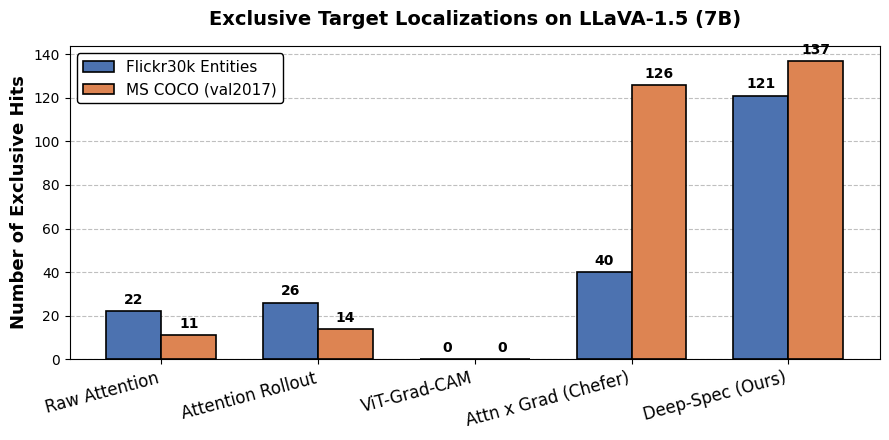

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


methods = [
    'Raw Attention',
    'Attention Rollout',
    'ViT-Grad-CAM',
    'Attn x Grad (Chefer)',
    'Deep-Spec (Ours)'
]

# using this data from what we got in above experiments. just to create a single plot explaining both datasets
flickr_hits = [22, 26, 0, 40, 121]
coco_hits = [11, 14, 0, 126, 137]

x = np.arange(len(methods))
width = 0.35


fig, ax = plt.subplots(figsize=(9, 4.5))

color_flickr = '#4C72B0'
color_coco = '#DD8452'

rects1 = ax.bar(x - width/2, flickr_hits, width, label='Flickr30k Entities',
                color=color_flickr, edgecolor='black', linewidth=1.2)
rects2 = ax.bar(x + width/2, coco_hits, width, label='MS COCO (val2017)',
                color=color_coco, edgecolor='black', linewidth=1.2)


ax.set_ylabel('Number of Exclusive Hits', fontsize=13, fontweight='bold')
ax.set_title('Exclusive Target Localizations on LLaVA-1.5 (7B)', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(methods, fontsize=12, rotation=15, ha='right')

ax.legend(fontsize=11, frameon=True, framealpha=1, edgecolor='black', loc='upper left')

ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle='--', color='gray', alpha=0.5)


def autolabel(rects):
    """Attach a text label above each bar displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{int(height)}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()

pdf_filename = 'Deep_Spec_Combined_Exclusive_Hits.pdf'
plt.savefig(pdf_filename, format='pdf', dpi=300, bbox_inches='tight')
plt.show()

